In [ ]:
!pip install kaggle

KeyboardInterrupt: 

In [ ]:
import os

# Set your credentials
os.environ['KAGGLE_USERNAME'] = "miniproject129"
os.environ['KAGGLE_KEY'] = "KGAT_9f8f788ab142502de5a35b4b5fe13199"

# Now run the download command
!kaggle datasets download -d manmandes/malimg

Dataset URL: https://www.kaggle.com/datasets/manmandes/malimg
License(s): unknown
Resuming from 384827392 bytes (790721158 bytes left)...
100% 1.09G/1.09G [00:21<00:00, 37.4MB/s]



In [ ]:
!unzip -q malimg.zip -d malimg_data

In [ ]:
!ls /content/malimg_data/malimg_dataset/test

 Adialer.C	  C2LOP.P	   Lolyda.AA3	   'Swizzor.gen!I'
 Agent.FYI	  Dialplatform.B   Lolyda.AT	    VB.AT
 Allaple.A	  Dontovo.A	  'Malex.gen!J'     Wintrim.BX
 Allaple.L	  Fakerean	   Obfuscator.AD    Yuner.A
'Alueron.gen!J'   Instantaccess   'Rbot!gen'
 Autorun.K	  Lolyda.AA1	   Skintrim.N
'C2LOP.gen!g'	  Lolyda.AA2	  'Swizzor.gen!E'


In [ ]:
!nvidia-smi

Thu Mar 19 14:08:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define your paths based on your screenshot
base_path = '/content/malimg_data/malimg_dataset/'

# Initialize generators
datagen = ImageDataGenerator(rescale=1./255)

# Load Training Data
train_gen = datagen.flow_from_directory(
    base_path + 'train', target_size=(224, 224), batch_size=32, class_mode='categorical')

# Load Validation Data
val_gen = datagen.flow_from_directory(
    base_path + 'val', target_size=(224, 224), batch_size=32, class_mode='categorical')

# Load Test Data (keep shuffle=False for the final report)
test_gen = datagen.flow_from_directory(
    base_path + 'test', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False)

Found 7459 images belonging to 25 classes.
Found 923 images belonging to 25 classes.
Found 957 images belonging to 25 classes.


In [ ]:
# Load pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Construct the MalVision Architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Regularization to prevent overfitting
    layers.Dense(25, activation='softmax') # 25 output classes for Malimg
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Run training (10 epochs is usually sufficient for transfer learning)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
143/234 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.4509 - loss: 2.1811

KeyboardInterrupt: 

NameError: name 'history' is not defined

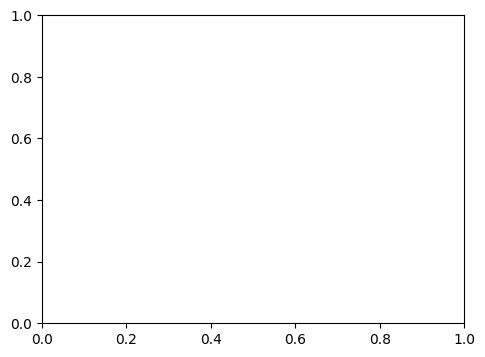

In [ ]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the unseen test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Get predictions for the test set
# Ensure shuffle=False was used in your test_gen in Cell 9
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

# 2. Print Classification Report (Precision, Recall, F1)
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()))
plt.title('Malware Family Confusion Matrix')
plt.ylabel('Actual Family')
plt.xlabel('Predicted Family')
plt.show()

In [ ]:
# Save the entire model (architecture + weights + optimizer)
model.save('malvision_model.h5')
print("Model saved as malvision_model.h5")

# Option: Download to your computer automatically
from google.colab import files
files.download('malvision_model.h5')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Redefining the Architecture with Pattern-Focus
model = models.Sequential([
    # This layer chops off the top 30 pixels (the 'header')
    layers.Cropping2D(cropping=((30, 0), (0, 0)), input_shape=(224, 224, 3)),

    # Resize back to 224x224 so the VGG16 base stays happy
    layers.Resizing(224, 224),

    base_model, # Your VGG16 base
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Setting up the 'Safety Switches' for 80 Epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,            # Stop if no improvement for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

print("Model upgraded to Pattern-Matching mode.")

Model upgraded to Pattern-Matching mode.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/cropping2d.py:57: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# 3. Training the Model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=80,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 63s 255ms/step - accuracy: 0.6168 - loss: 1.5441 - val_accuracy: 0.8418 - val_loss: 0.7801 - learning_rate: 0.0010
Epoch 2/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 47s 198ms/step - accuracy: 0.8359 - loss: 0.6899 - val_accuracy: 0.9014 - val_loss: 0.4487 - learning_rate: 0.0010
Epoch 3/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 45s 193ms/step - accuracy: 0.8818 - loss: 0.4760 - val_accuracy: 0.9057 - val_loss: 0.3467 - learning_rate: 0.0010
Epoch 4/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 46s 195ms/step - accuracy: 0.8956 - loss: 0.3871 - val_accuracy: 0.9068 - val_loss: 0.2862 - learning_rate: 0.0010
Epoch 5/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 46s 194ms/step - accuracy: 0.9055 - loss: 0.3301 - val_accuracy: 0.9393 - val_loss: 0.2507 - learning_rate: 0.0010
Epoch 6/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 46s 195ms/step - accuracy: 0.9159 - loss: 0.2870 - val_accuracy: 0.9372 - val_loss: 0.2162 - learning_rate: 0.0010
Epoch 7/80
234/234 ━━━━━━━━━━━━━━━━━━━━ 46s 194ms/step - accuracy: 0.9

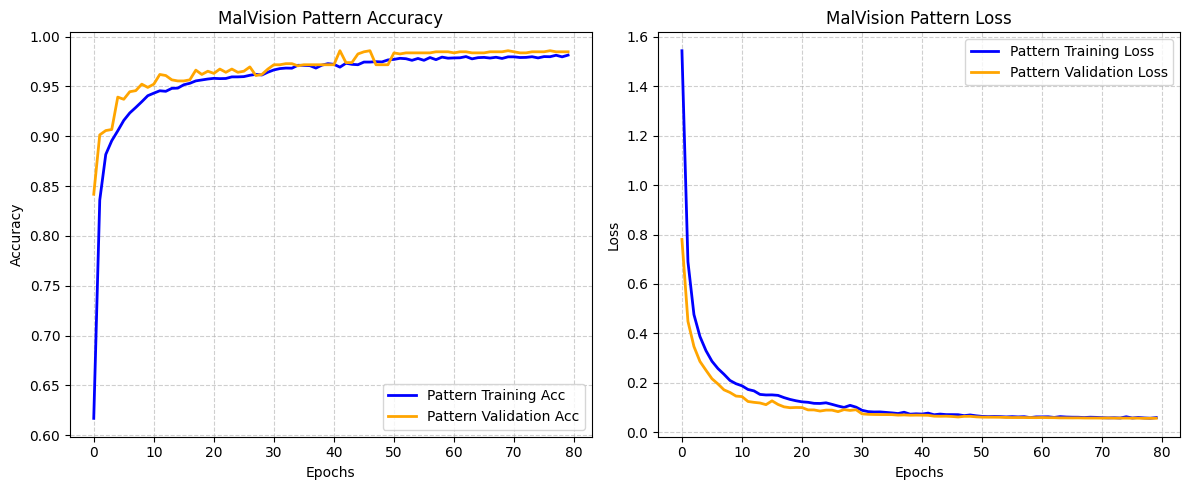


--- Final Model Evaluation ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 623ms/step - accuracy: 0.9843 - loss: 0.0587
Final Test Accuracy (Pattern-Based): 98.43%
Success: Model generalizes well (Gap: -0.33%).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Pattern Training Acc', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Pattern Validation Acc', color='orange', linewidth=2)
plt.title('MalVision Pattern Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pattern Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Pattern Validation Loss', color='orange', linewidth=2)
plt.title('MalVision Pattern Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Final Evaluation on Unseen Test Set
print("\n--- Final Model Evaluation ---")
test_loss, test_acc = model.evaluate(test_gen)
print(f"Final Test Accuracy (Pattern-Based): {test_acc*100:.2f}%")

# 4. Quick Check: Are we overfitting?
gap = (history.history['accuracy'][-1] - history.history['val_accuracy'][-1]) * 100
if gap > 5:
    print(f"Warning: Overfitting detected (Gap: {gap:.2f}%). Consider more Dropout.")
else:
    print(f"Success: Model generalizes well (Gap: {gap:.2f}%).")

In [ ]:
# 1. Save the model to the Colab local file system
# We'll name it 'malvision_model.h5' to distinguish it from the old version
model.save('malvision_model.h5')
print("Model saved to Colab disk as malvision_pattern_model.h5")

# 2. Trigger the download to your computer
from google.colab import files
files.download('malvision_model.h5')

Model saved to Colab disk as malvision_pattern_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>